In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

*ESERCIZIO 1*

In [2]:
def fwsub(A,b):
  """
  Algoritmo di sostituzione in avanti - forward substitution
  Input:
  A: matrice quadrata triangolare inferiore
  b: termine noto
  Output:
  x: soluzione del sistema lineare = b
  """
  # dimesinoe termine noto b
  n = b.shape[0]
  # Verifichiamo che la matrice sia quadrata
  if A.shape[0] != A.shape[1]:
   raise RuntimeError("ERRORE: matrice non quadrata")
  # Verifichiamo che la matrice sia triangolare inferiore
  if (A != np.tril(A)).any():
    raise RuntimeError("ERRORE: matrice non triangolare inferiore")
  # Verifichiamo che la matrice sia invertibile
  # Essendo triangolare, i suoi autovalori si trovano sulla diagonale principale
  if np.prod(np.diag(A)) == 0:
    raise RuntimeError("ERRORE: matrice singolare")

  #inizializzo il vettore
  x = np.zeros(n)
  # costruzione forward substitution
  x[0] = b[0] / A[0, 0]
  for i in range(1, n):
    x[i] = (b[i] - A[i, 0:i] @ x[0:i]) / A[i, i]
   
  return x

def bksub(A,b):
  """
  Algoritmo di sostituzione all'indietro - backward substitution
  Input:
  A: matrice quadrata triangolare superiore
  b: termine noto
  Output:
  x: soluzione del sistema lineare = b
  """
  n = b.shape[0]

  #Verifica matrice quadrata
  if (A.shape[0]!=A.shape[1]):
    raise RuntimeError("ERRORE: matrice non quadrata")
  
  #verifica matrice triangolare superiore
  if (A != np.triu(A)).any():
    raise RuntimeError("ERRORE: matrice non triangolare superiore")
  
  if np.prod(np.diag(A))==0:
    raise RuntimeError ("ERRORE: matrice singolare")

  x=np.zeros(n)
  x[-1] = b[-1] / A[-1, -1]

  for i in range (n-2, -1 , -1): #-1 perché ultimo elemento del range è escluso quindi per andare da n-2 a zero devo scrivere range da n-2 a -1
    # l'ultimo -1 invece serve per far andare il contatore da n-2 a zero (quindi a ogni ciclo sottraggo 1 a i)
    x[i] = (b[i] - A[i, i + 1: n] @ x[i + 1: n]) / A[i, i] # somma da 1 a n-1 nella realtà ma poiché ultimo elemento non viene contato nel ciclo metto fino a n per avere quello che voglio
          
  return x

In [3]:
N=np.array([5, 10, 20])
err=[]
cond=[]
for n in N:
    A=scipy.linalg.hilbert(n)
    x_ex=np.ones(n)
    b= A @ x_ex
    P,L,U=scipy.linalg.lu(A)
    y=fwsub(L, P.T@b)
    x=bksub(U,y)
    err.append(np.max(np.abs(x-x_ex)))
    cond.append(np.linalg.cond(A))

print(cond)
print(err)


[np.float64(476607.2502422687), np.float64(16024413500363.82), np.float64(1.3193976166344822e+18)]
[np.float64(2.5413005033669833e-11), np.float64(0.00014159683684566993), np.float64(115.31796733420448)]


In [9]:
#il condizionamento di una matrice è importante per determinare la stabilità del metodo, 
#cioé capire come varia la soluzione quando i dati vengono perturbati.
#ipotizzando di aver eperturbazioni solo sul termine noto, allora l'errore relativo 
#commesso con il MEG è dato da 1/cond(A)deltab/b<err<cond(a)*deltab/B.
#QUindi se una matrice è ben condizionata -->cond1. mentre una matrice è mal condizionata
# se cond(A)>>1 e quidìndi anche con piccoli delta b si hanno grandi delta x 

*ESERCIZIO 2*

In [12]:
from scipy.sparse.linalg import cg
niter=[]
err=[]
for n in N: 
    x0=np.zeros(n)
    xcg=[x0]
    A=scipy.linalg.hilbert(n)
    x_ex=np.ones(n)
    b= A@x_ex
    x_finale, info= cg(A, b,x0,rtol=1e-12 ,maxiter=100, callback= lambda xk: xcg.append(xk))
    err.append(np.max(np.abs(x_finale-x_ex)))
    niter.append(len(xcg)-1)
    print(niter)
    print(err)

[7]
[np.float64(1.5528689445432065e-12)]
[7, 13]
[np.float64(1.5528689445432065e-12), np.float64(8.767338031789862e-05)]
[7, 13, 18]
[np.float64(1.5528689445432065e-12), np.float64(8.767338031789862e-05), np.float64(4.32641316707727e-05)]


[np.float64(1.4863658023634645), np.float64(1.040246155181106), np.float64(5.955949689590156)]


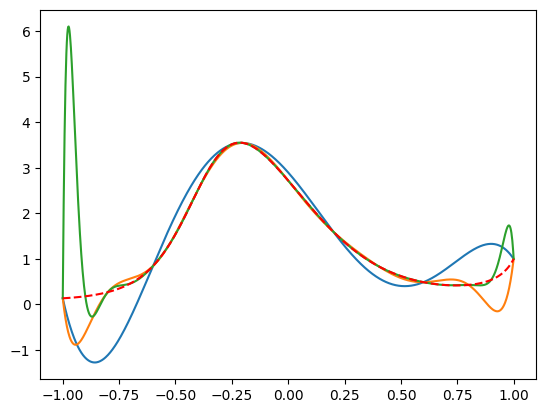

In [19]:
from numpy import polyfit, polyval

f=lambda x: np.exp(np.cos(np.pi*x))/(np.exp(-x)+np.sin(np.pi*x))
a,b=-1, 1
N=[5,10,20]
xx=np.linspace(a, b, 1000)
err=[]
for n in N:
    x_nodes=np.linspace(a,b, n+1)
    y_nodes=f(x_nodes)
    p=polyfit(x_nodes, y_nodes, deg=n)
    L=lambda x: polyval(p, xx)
    plt.plot(xx, L(xx))
    err.append(np.max(np.abs(L(xx)- f(xx))))
plt.plot(xx, f(xx), '--r')
print(err)

[np.float64(0.9896491306278854), np.float64(0.16970418641345297), np.float64(0.004442854499715487)]


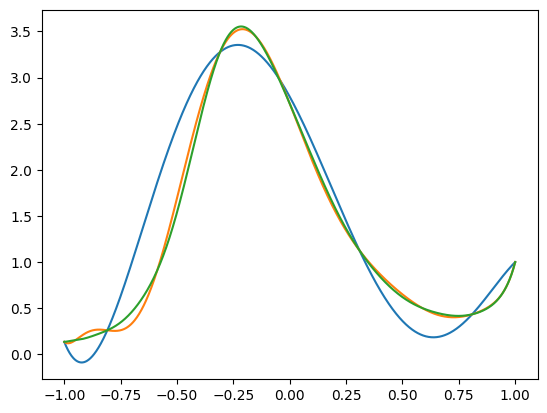

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import polyfit, polyval
f=lambda x: np.exp(np.cos(np.pi*x))/(np.exp(-x)+np.sin(np.pi*x))
a,b=-1, 1
N=[5,10,20]
xx=np.linspace(a, b, 1000)
err=[]
for n in N:
    #definisco nodi di Chebychev
    i=np.arange(0,n+2)
    x_hat=-np.cos(np.pi*i/n)
    x_nodes=(b+a)/2+(b-a)/2*x_hat

    p=polyfit(x_nodes, f(x_nodes), n)
    y=lambda x: polyval (p, xx)

    err.append(np.max(np.abs(y(xx)-f(xx))))
    plt.plot(xx, y(xx))

print(err)


In [7]:
#PRORPRITTà DI CONVERGENZA INTERPOLANTE LAGRANGIANA:
#l'interpolante lagrangiana all'aumentare di n approssima meglio i 
#nodi centrali ma all'estremità si verificano maggiori oscillazioni,
#infatti si vede molto bene del grafico rappresentato e dal vettore degli errori al variare di n:
#l'errore aumenta e si ha una grande oscillazione agli estremi (fenomeno di Runge)

#per quanto riguarda la stabilità dell'interpolante lagrangiana ci chiediamo quanto vale l'erroe
#che commettiamo se approssimiamo con un polinomio pi' una funzione perturbata f'. 
#err=max|pi-pi'|=max|sommatoria(f*L -f'L)|<= max|f-f'|*max|somma L|
#introducendo la costante di Lebesgue=max|somma L|=2^(n+1)/(n*e*lon(gamma*n)) abbiamo che 
#tale costante esplode all'aumentare di n, per cui si perde il controllo dell'errore e quindi si perde la stabilità



*ESERCIZIO 3*

In [2]:
import numpy as np


In [3]:
def eulero_avanti(f, t0, tN, y0, h):
    """
    Metodo di Eulero in avanti (Forward Euler).

    Risolve il problema ai valori iniziali:
        y'(t) = f(t, y(t)),  t ∈ [t0, tN]
        y(t0) = y0

    utilizzando lo schema esplicito:
        y_{n+1} = y_n + h*f(t_n, y_n)

    Input:
        f (callable): Funzione che rappresenta il termine di destra dell'ODE: f(t, y)
        t0 (float): Tempo iniziale
        tN (float): Tempo finale
        y0 (float, list o numpy.ndarray): Condizione iniziale (scalare o vettore)
        h (float): Passo temporale

    Output:
        t_h (numpy.ndarray): Vettore degli istanti temporali (lunghezza N+1)
        u_h (numpy.ndarray): Soluzione discreta nei nodi temporali (matrice d × N+1)

    Avvertenza:
        Verificare che l'output di f e il dato y0 siano vettori della stessa lunghezza!

    Nota:
        Se la dimensione di y0 è 1, la soluzione è un array di lunghezza N+1.
        Il metodo è esplicito e facile da implementare ma ha requisiti stringenti
        sulla stabilità (CFL condition).
    """
    # Trasforma y0 in un vettore 1d
    y0 = np.atleast_1d(y0)

    # Determina il numero di passi temporali N e la dimensione di y0
    N = int((tN - t0) / h)
    d = len(y0)

    # Inizializza la matrice soluzione
    u_h = np.zeros((d, N+1))
    # Abbiamo N passi temporali, quindi N+1 nodi
    t_h = np.zeros(N+1)

    # Ciclo iterativo che calcola i passi di Eulero esplicito
    u_h[:, 0] = y0
    t_h[0] = t0

    for i in range(N):
        u_h[:, i+1] = u_h[:, i] + h*f(t_h[i], u_h[:, i])
        t_h[i+1] = t_h[i]+h

    if (d == 1):
        u_h = np.squeeze(u_h)

    return t_h, u_h

In [8]:

m=1
alpha=5
beta=np.pi/12
t0=0
T=4
F=lambda x: alpha*x - beta*x**3

N=[5, 20, 80]
x_0, v_0= 1,0
for n in N:
    th, uh=eulero_avanti(F, t0, T, u_0, h=T/n)

    

TypeError: <lambda>() takes 1 positional argument but 2 were given